# Chapter 1 - Curves

Source orientation: do Carmo, *Differential Geometry of Curves and Surfaces*, Chapter 1, printed pp. 1-52 / PDF pp. 17-68. The source map is `pdf_page = printed_page + 16`.

Goal: separate clock-dependent features of a parametrized curve from local and global geometry of the trace, using direct plots, symbolic checks, and generated chapter artifacts.

## Translation Guide

- **parametrized curve**: a map `alpha(t)` sampled as an array of points, with velocity stored separately from the trace.
- **singular point**: a sample where speed is zero or numerically tiny; the tangent line is not certified there.
- **regular point**: a nonzero velocity vector, so tangent geometry is well defined.
- **arc length**: a cumulative integral of speed that can be used as a monotone clock.
- **vector product**: `np.cross`, used to orient the binormal and the Frenet frame.
- **Frenet frame**: three moving orthonormal vectors `T`, `N`, `B` computed from derivatives with respect to arc length.
- **curvature and torsion**: scalar fields measuring bending inside the osculating plane and signed twisting out of it.
- **local canonical form**: Taylor coefficients in the `T,N,B` basis.
- **global plane diagnostics**: rotation index, isoperimetric quotient, and curvature-vertex count for closed curves.

## Route Through the Chapter

1. Separate trace from parametrization, including singular and multiple-traversal examples.
2. Use speed to detect regularity and reparametrize by length.
3. Use the vector product to build the Frenet frame.
4. Check curvature and do Carmo torsion symbolically and numerically on a helix.
5. Read local shape from the canonical Taylor form and osculating circle.
6. Test global plane-curve behavior with turning number, isoperimetric deficit, and vertices.

The source chapter supplies the order of ideas and the mathematical landmarks. This notebook rebuilds those landmarks with fresh prose, executable examples, generated artifacts, and numerical checks. The goal is to learn the geometry by manipulating objects rather than by passively reading formula lists.

In [1]:
from pathlib import Path
import json
import math
import os
import sys

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

def find_book_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    upward = [start, *start.parents]
    for candidate in upward:
        if (candidate / '00-book-index.ipynb').exists() and (candidate / 'utils').is_dir():
            return candidate
    for base in upward:
        if base.exists() and base.is_dir():
            for child in base.iterdir():
                if child.is_dir() and (child / '00-book-index.ipynb').exists() and (child / 'utils').is_dir():
                    return child
    raise RuntimeError('Could not locate the course root')

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_path, assert_artifact, display_artifact, save_figure, save_plotly_html, write_json
from utils.dg_curves import cumulative_arc_length, finite_difference, osculating_circle

UNIT = 'chapter-01'
SOURCE_SPAN = {'printed_pages': '1-52', 'pdf_pages': '17-68', 'source_map': 'pdf_page = printed_page + 16'}
COLORS = {'ink': '#172033', 'slate': '#64748b', 'blue': '#2563eb', 'green': '#059669', 'red': '#dc2626', 'orange': '#ea580c', 'purple': '#7c3aed', 'teal': '#0f766e'}
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.22})
ARTIFACTS, CHECKS = {}, {}

def rel(path):
    path = Path(path).resolve()
    try:
        return path.relative_to(BOOK_ROOT.resolve()).as_posix()
    except ValueError:
        return path.as_posix()

def nb_rel(path):
    return Path(os.path.relpath(Path(path).resolve(), Path.cwd().resolve())).as_posix()

def remember(name, path):
    ARTIFACTS[name] = Path(path)
    return Path(path)

def write_check(name, filename, data):
    path = write_json(data, UNIT, 'checks', filename)
    return remember(name, path)

def finish_equal(ax, title, xlabel='x', ylabel='y'):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='#cbd5e1', lw=0.8)
    ax.axvline(0, color='#cbd5e1', lw=0.8)

def set_3d_equal(ax, pts):
    pts = np.asarray(pts)
    mins, maxs = pts.min(axis=0), pts.max(axis=0)
    centers = 0.5 * (mins + maxs)
    radius = 0.52 * float(np.max(maxs - mins))
    for setter, center in zip([ax.set_xlim, ax.set_ylim, ax.set_zlim], centers):
        setter(center - radius, center + radius)

write_check('source_span', 'source-span.json', SOURCE_SPAN)
print(f'BOOK_ROOT = {rel(BOOK_ROOT)}')

BOOK_ROOT = .


## The curve is the map, not just the trace

A circle drawn twice and a circle drawn once have the same set of points but not the same velocity field. That distinction is the first computational habit of the chapter. In the notebook a curve is represented as a function and as a sample table, so the trace, the parameter, the speed, and the tangent can be inspected separately. This prevents a common misconception: geometry ignores a bad clock only after we have checked that the clock never stops. A cusp or a stationary point is not a harmless cosmetic detail; it is the place where tangent-line geometry loses its certificate.

In this course folder, the corresponding artifact is generated from book-local code and stored under `artifacts/chapter-01/`. The artifact is part of the explanation: read the labels, inspect the parameters, and compare the plotted behavior with the invariant named in the surrounding prose.

## Arc length is a better clock

Once speed is nonzero, the cumulative length function is monotone and can be used to replace the original parameter. This is more than a convenience. Unit-speed parametrization makes formulas shorter because the tangent vector has fixed length and its derivative points only in the normal direction. The arc-length visual records the old parameter on the horizontal axis and accumulated distance on the vertical axis. The curve becomes easier to reason about when equal steps on the clock mean equal distance along the object.

In this course folder, the corresponding artifact is generated from book-local code and stored under `artifacts/chapter-01/`. The artifact is part of the explanation: read the labels, inspect the parameters, and compare the plotted behavior with the invariant named in the surrounding prose.

## Frenet data turns motion into geometry

The Frenet frame packages the local theory into three inspectable vectors. The tangent points along the curve, the normal points toward the first-order change in tangent, and the binormal records the oriented osculating plane. Curvature is the rate at which the tangent turns per unit length. Torsion is the rate at which the osculating plane twists. For a helix the formulas are constant, so it is the right calibration object: if the numerical curvature and torsion are not essentially constant, the implementation or the sampling is suspect.

In this course folder, the corresponding artifact is generated from book-local code and stored under `artifacts/chapter-01/`. The artifact is part of the explanation: read the labels, inspect the parameters, and compare the plotted behavior with the invariant named in the surrounding prose.

## Local canonical form and osculating circles

Near a regular point, the curve can be read in a moving frame. First-order data gives the tangent line, second-order data gives the curvature direction, and third-order data begins to see torsion. The osculating circle visual is a local microscope: at the chosen point it shares position, tangent, and curvature with the curve. The circle is not a decorative overlay; it is the geometric meaning of the scalar kappa. When curvature is large, the circle is small. When curvature is near zero, the circle recedes and the curve looks locally straight.

In this course folder, the corresponding artifact is generated from book-local code and stored under `artifacts/chapter-01/`. The artifact is part of the explanation: read the labels, inspect the parameters, and compare the plotted behavior with the invariant named in the surrounding prose.

## Global plane-curve tests

The final part of the chapter changes scale. A plane curve can have local curvature everywhere and still exhibit global facts: turning number, total curvature, convexity behavior, and singular or asymptotic features. The notebook uses sampled examples rather than copied exercises. Learners compare a smooth trace, a curve with a problematic clock, and a curve whose turning accumulates. The aim is to make local differential invariants feel like instruments that can also diagnose global behavior when integrated carefully.

In this course folder, the corresponding artifact is generated from book-local code and stored under `artifacts/chapter-01/`. The artifact is part of the explanation: read the labels, inspect the parameters, and compare the plotted behavior with the invariant named in the surrounding prose.

## Build the Chapter-Specific Visual Storyboard

The next cell creates the durable artifacts directly from Chapter 1 concepts. Static PNGs support long-term review; the HTML helix preserves 3D frame rotation. Each artifact has an inspection target and a numerical or symbolic invariant.

In [2]:
paths = {}
checks = {}

storyboard = [
    {'concept': 'regular parametrizations and singularities', 'artifact': 'figures/regular-parametrizations-and-singularities.png', 'library': 'Matplotlib', 'invariant': 'speed detects singular samples'},
    {'concept': 'arc length', 'artifact': 'figures/arc-length-clock.png', 'library': 'Matplotlib + NumPy quadrature', 'invariant': 'arc length is monotone and totals 2*pi on the circle'},
    {'concept': 'Frenet frame, curvature, torsion', 'artifact': 'figures/helix-frenet-frame.png and interactive/helix-trace-and-frame.html', 'library': 'Matplotlib, Plotly, SymPy', 'invariant': 'orthonormal frame and Frenet residuals'},
    {'concept': 'local canonical form', 'artifact': 'figures/local-canonical-form-projections.png and figures/osculating-circle-curvature.png', 'library': 'Matplotlib', 'invariant': 'torsion sign and osculating contact'},
    {'concept': 'global plane-curve diagnostics', 'artifact': 'figures/global-plane-curve-diagnostics.png and tables/plane-curve-diagnostics.csv', 'library': 'NumPy, Pandas, Matplotlib', 'invariant': 'rotation index, isoperimetric quotient, vertex count'},
]
write_check('visual_storyboard', 'visual-storyboard.json', {'source_span': SOURCE_SPAN, 'items': storyboard})

G = nx.DiGraph([('parametrized map', 'velocity'), ('velocity', 'regularity'), ('regularity', 'arc length'), ('vector product', 'Frenet frame'), ('arc length', 'Frenet frame'), ('Frenet frame', 'curvature kappa'), ('Frenet frame', 'torsion tau'), ('curvature kappa', 'local canonical form'), ('torsion tau', 'local canonical form'), ('curvature kappa', 'global plane diagnostics'), ('arc length', 'global plane diagnostics')])
pos = {'parametrized map': (0, 2), 'velocity': (1.2, 2), 'regularity': (2.4, 2), 'arc length': (3.6, 2), 'vector product': (2.4, .8), 'Frenet frame': (4.8, 1.35), 'curvature kappa': (6, 2.05), 'torsion tau': (6, .75), 'local canonical form': (7.4, 1.35), 'global plane diagnostics': (7.4, 2.5)}
fig, ax = plt.subplots(figsize=(10.8, 4.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle='-|>', arrowsize=15, width=1.5, edge_color='#64748b')
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2400, node_color='#dbeafe', edgecolors='#334155')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color=COLORS['ink'])
ax.set_title('Chapter 1 invariant route: from moving point to local and global data')
ax.set_axis_off()
paths['route_map'] = str(remember('route_map', save_figure(fig, UNIT, 'figures', 'chapter-route-invariant-map.png')))
plt.close(fig)

# Regularity, singularities, and trace-vs-map.
t = np.linspace(-2, 2, 700)
cusp = np.column_stack([t**3, t**2])
cv = np.column_stack([3*t**2, 2*t])
cspeed = np.linalg.norm(cv, axis=1)
u = np.linspace(0, 2*np.pi, 500)
circle1 = np.column_stack([np.cos(u), np.sin(u)])
circle2 = np.column_stack([np.cos(2*u), np.sin(2*u)])
v1 = np.column_stack([-np.sin(u), np.cos(u)])
v2 = np.column_stack([-2*np.sin(2*u), 2*np.cos(2*u)])
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
sc = axes[0].scatter(cusp[:,0], cusp[:,1], c=cspeed, s=8, cmap='viridis')
for sample in [-1.35, -.65, .65, 1.35]:
    idx = int(np.argmin(np.abs(t-sample))); p = cusp[idx]; v = .28*cv[idx]/np.linalg.norm(cv[idx])
    axes[0].arrow(p[0], p[1], v[0], v[1], head_width=.05, length_includes_head=True, color=COLORS['red'])
axes[0].scatter([0], [0], s=65, color=COLORS['orange'], edgecolor='white', zorder=4, label='zero speed')
axes[0].legend(loc='upper left'); finish_equal(axes[0], 'Singular sample: velocity vanishes', 'x(t)', 'y(t)')
fig.colorbar(sc, ax=axes[0], fraction=.046, pad=.04, label='speed')
axes[1].plot(circle1[:,0], circle1[:,1], color=COLORS['blue'], lw=2, label='one traversal')
axes[1].plot(circle2[:,0], circle2[:,1], color=COLORS['orange'], lw=1.2, ls='--', label='two traversals')
for idx in [35, 120, 230, 355]:
    p = circle1[idx]; q = circle2[idx]
    axes[1].arrow(p[0], p[1], .22*v1[idx,0], .22*v1[idx,1], head_width=.04, color=COLORS['blue'], length_includes_head=True)
    axes[1].arrow(q[0], q[1], .11*v2[idx,0], .11*v2[idx,1], head_width=.04, color=COLORS['orange'], length_includes_head=True)
axes[1].legend(loc='upper right'); finish_equal(axes[1], 'Same trace, different parametrized maps')
paths['regularity'] = str(remember('regularity', save_figure(fig, UNIT, 'figures', 'regular-parametrizations-and-singularities.png')))
plt.close(fig)
checks['regularity'] = {'cusp_min_speed': float(cspeed.min()), 'circle_once_min_speed': float(np.linalg.norm(v1, axis=1).min()), 'circle_twice_speed_ratio': float(np.linalg.norm(v2, axis=1).mean()/np.linalg.norm(v1, axis=1).mean())}
write_check('regularity_checks', 'regularity-checks.json', checks['regularity'])

# Arc length clock on a nonuniform parametrization of the unit circle.
u = np.linspace(0, 2*np.pi, 900)
theta = u + .35*np.sin(u)
clocked = np.column_stack([np.cos(theta), np.sin(theta), np.zeros_like(theta)])
speed_exact = 1 + .35*np.cos(u)
arc = cumulative_arc_length(clocked, u)
equal_u_idx = [int(np.argmin(np.abs(u-x))) for x in np.linspace(0, 2*np.pi, 18, endpoint=False)]
equal_s = np.linspace(0, arc[-1], 18, endpoint=False)
equal_s_idx = [int(np.argmin(np.abs(arc-x))) for x in equal_s]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(clocked[:,0], clocked[:,1], color=COLORS['slate'], lw=1.5)
axes[0].scatter(clocked[equal_u_idx,0], clocked[equal_u_idx,1], s=40, color=COLORS['orange'], label='equal parameter')
axes[0].scatter(clocked[equal_s_idx,0], clocked[equal_s_idx,1], s=18, color=COLORS['blue'], label='equal arc length')
axes[0].legend(loc='upper right'); finish_equal(axes[0], 'Clock artifacts disappear after length reparametrization')
axes[1].plot(u, speed_exact, color=COLORS['orange'], lw=2, label="speed |alpha'(u)|")
axes[1].plot(u, arc, color=COLORS['blue'], lw=2, label='accumulated length s(u)')
axes[1].set_title('Positive speed makes s(u) monotone'); axes[1].set_xlabel('original parameter u'); axes[1].legend(loc='upper left')
paths['arc_clock'] = str(remember('arc_clock', save_figure(fig, UNIT, 'figures', 'arc-length-clock.png')))
plt.close(fig)
checks['arc_length'] = {'speed_min': float(speed_exact.min()), 'arc_length_monotone': bool(np.all(np.diff(arc) > -1e-10)), 'total_length_error_vs_2pi': float(abs(arc[-1] - 2*np.pi))}
write_check('arc_length_checks', 'arc-length-checks.json', checks['arc_length'])

# Symbolic helix check under do Carmo's torsion sign convention.
a, b, tt = sp.symbols('a b tt', positive=True, real=True)
r = sp.Matrix([a*sp.cos(tt), a*sp.sin(tt), b*tt]); r1 = r.diff(tt); r2 = r1.diff(tt); r3 = r2.diff(tt)
cross = r1.cross(r2); speed_sq = sp.simplify(r1.dot(r1))
kexpr = sp.simplify(sp.sqrt(cross.dot(cross)) / speed_sq**sp.Rational(3,2))
tauexpr = sp.simplify(-cross.dot(r3) / cross.dot(cross))
assert sp.simplify(kexpr - a/(a*a+b*b)) == 0
assert sp.simplify(tauexpr + b/(a*a+b*b)) == 0
checks['symbolic_helix'] = {'curvature_identity_zero': str(sp.simplify(kexpr - a/(a*a+b*b))), 'torsion_identity_zero': str(sp.simplify(tauexpr + b/(a*a+b*b))), 'torsion_convention': "B_prime = tau N"}
write_check('symbolic_formulas', 'symbolic-formulas.json', checks['symbolic_helix'])

# Frenet frame on a helix.
a0, b0 = 1.0, .35; c0 = math.sqrt(a0*a0 + b0*b0); u = np.linspace(0, 6*np.pi, 760)
helix = np.column_stack([a0*np.cos(u), a0*np.sin(u), b0*u])
T = np.column_stack([-a0*np.sin(u), a0*np.cos(u), np.full_like(u, b0)]) / c0
N = np.column_stack([-np.cos(u), -np.sin(u), np.zeros_like(u)]); B = np.cross(T, N); s_arc = c0*u
k0 = a0/(a0*a0+b0*b0); tau0 = -b0/(a0*a0+b0*b0)
Ts, Ns, Bs = finite_difference(T, s_arc), finite_difference(N, s_arc), finite_difference(B, s_arc); core = slice(20, -20)
checks['frenet_frame'] = {'expected_kappa': float(k0), 'expected_tau_do_carmo': float(tau0), 'max_abs_T_cross_N_minus_B': float(np.max(np.linalg.norm(np.cross(T,N)-B, axis=1))), 'frenet_T_prime_residual': float(np.max(np.linalg.norm(Ts[core]-k0*N[core], axis=1))), 'frenet_N_prime_residual': float(np.max(np.linalg.norm(Ns[core]-(-k0*T[core]-tau0*B[core]), axis=1))), 'frenet_B_prime_residual': float(np.max(np.linalg.norm(Bs[core]-tau0*N[core], axis=1)))}
write_check('frenet_frame_invariants', 'frenet-frame-invariants.json', checks['frenet_frame'])
fig = plt.figure(figsize=(9, 6.6)); ax = fig.add_subplot(111, projection='3d')
ax.plot(helix[:,0], helix[:,1], helix[:,2], color=COLORS['blue'], lw=2.1)
for idx in [80,190,310,430,560,680]:
    p = helix[idx]; scale = .42
    ax.quiver(*p, *(scale*T[idx]), color=COLORS['green'], linewidth=1.4)
    ax.quiver(*p, *(scale*N[idx]), color=COLORS['red'], linewidth=1.4)
    ax.quiver(*p, *(scale*B[idx]), color=COLORS['purple'], linewidth=1.4)
ax.legend(handles=[Line2D([0],[0],color=COLORS['blue'],lw=2,label='helix'), Line2D([0],[0],color=COLORS['green'],lw=2,label='T'), Line2D([0],[0],color=COLORS['red'],lw=2,label='N'), Line2D([0],[0],color=COLORS['purple'],lw=2,label='B')], loc='upper left')
ax.set_title('Frenet frame along a circular helix'); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z'); set_3d_equal(ax, helix)
paths['frenet_frame'] = str(remember('frenet_frame', save_figure(fig, UNIT, 'figures', 'helix-frenet-frame.png')))
plt.close(fig)
fig3 = go.Figure(); fig3.add_trace(go.Scatter3d(x=helix[:,0], y=helix[:,1], z=helix[:,2], mode='lines', name='helix', line={'color': COLORS['blue'], 'width': 6}))
def add_segments(fig, points, vectors, name, color, scale=.55):
    xs, ys, zs = [], [], []
    for p, v in zip(points, vectors):
        q = p + scale*v; xs.extend([p[0], q[0], None]); ys.extend([p[1], q[1], None]); zs.extend([p[2], q[2], None])
    fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs, mode='lines', name=name, line={'color': color, 'width': 5}))
idx = np.array([80,190,310,430,560,680]); add_segments(fig3, helix[idx], T[idx], 'T', COLORS['green']); add_segments(fig3, helix[idx], N[idx], 'N', COLORS['red']); add_segments(fig3, helix[idx], B[idx], 'B', COLORS['purple'])
fig3.update_layout(title='Helix Frenet frame: rotate to inspect T, N, B', scene={'aspectmode': 'data'}, margin={'l':0,'r':0,'t':50,'b':0})
paths['interactive'] = str(remember('interactive', save_plotly_html(fig3, UNIT, 'interactive', 'helix-trace-and-frame.html', include_plotlyjs=True)))
html_path = Path(paths['interactive']); html_path.write_text('\n'.join(line.rstrip() for line in html_path.read_text(encoding='utf-8').splitlines()) + '\n', encoding='utf-8')

# Local canonical form and osculating circle.
s = np.linspace(-.55, .55, 500); kc, kpc, taun, taup = 1.35, .18, -.9, .9
def canon(tau):
    return np.column_stack([s - kc**2*s**3/6, .5*kc*s**2 + kpc*s**3/6, -kc*tau*s**3/6])
cn, cp = canon(taun), canon(taup)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, pair, title, labs in [(axes[0], (0,1), 'T-N projection: curvature is order 2', ('T','N')), (axes[1], (0,2), 'T-B projection: torsion sign is order 3', ('T','B')), (axes[2], (1,2), 'N-B projection: one-sided normal behavior', ('N','B'))]:
    ax.plot(cn[:,pair[0]], cn[:,pair[1]], color=COLORS['blue'], lw=2, label='tau < 0'); ax.plot(cp[:,pair[0]], cp[:,pair[1]], color=COLORS['orange'], lw=1.6, ls='--', label='tau > 0')
    ax.legend(loc='upper left'); finish_equal(ax, title, labs[0], labs[1])
paths['local_canonical'] = str(remember('local_canonical', save_figure(fig, UNIT, 'figures', 'local-canonical-form-projections.png')))
plt.close(fig)
s0 = np.linspace(-.75, .75, 500); ko = 1.2; curve = np.column_stack([s0 - ko**2*s0**3/6, .5*ko*s0**2, np.zeros_like(s0)])
circle = osculating_circle(np.zeros(3), np.array([1,0,0.]), np.array([0,1,0.]), 1/ko)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8)); axes[0].plot(curve[:,0], curve[:,1], color=COLORS['blue'], lw=2.2, label='curve'); axes[0].plot(circle[:,0], circle[:,1], color=COLORS['red'], lw=1.7, ls='--', label='osculating circle')
axes[0].legend(loc='upper right'); finish_equal(axes[0], 'Osculating circle has second-order contact', 'T', 'N')
circle_y = 1/ko - np.sqrt(np.maximum((1/ko)**2 - s0**2, 0)); residual = np.abs(curve[:,1] - circle_y); mask = np.abs(s0) > .04
axes[1].loglog(np.abs(s0[mask]), residual[mask], color=COLORS['teal'], lw=2); axes[1].loglog(np.abs(s0[mask]), .08*np.abs(s0[mask])**3, color=COLORS['slate'], ls='--', label='cubic guide')
axes[1].set_title('Contact residual is third order'); axes[1].set_xlabel('|s|'); axes[1].set_ylabel('vertical residual'); axes[1].legend(loc='lower right')
paths['osculating_circle'] = str(remember('osculating_circle', save_figure(fig, UNIT, 'figures', 'osculating-circle-curvature.png')))
plt.close(fig)
checks['local_canonical'] = {'negative_tau_positive_s_binormal_sign': float(np.sign(cn[s>.25,2].mean())), 'positive_tau_positive_s_binormal_sign': float(np.sign(cp[s>.25,2].mean())), 'osculating_radius': float(1/ko)}
write_check('local_canonical_checks', 'local-canonical-checks.json', checks['local_canonical'])

# Global plane-curve diagnostics.
def pder(points):
    dt = 2*np.pi/len(points); return (np.roll(points,-1,0)-np.roll(points,1,0))/(2*dt), (np.roll(points,-1,0)-2*points+np.roll(points,1,0))/(dt*dt), dt
def area_poly(points):
    x,y = points[:,0], points[:,1]; return .5*float(np.sum(x*np.roll(y,-1)-y*np.roll(x,-1)))
def rot_index(d1):
    ang = np.arctan2(d1[:,1], d1[:,0]); lift = np.unwrap(np.r_[ang, ang[0]]); return float((lift[-1]-lift[0])/(2*np.pi))
def vertex_count(k):
    if np.ptp(k) < 1e-3: return 'constant curvature'
    return int(np.sum(((k>np.roll(k,1))&(k>np.roll(k,-1))) | ((k<np.roll(k,1))&(k<np.roll(k,-1)))))
def diag(name, pts, simple=True):
    d1,d2,dt = pder(pts); spd = np.linalg.norm(d1, axis=1); k = (d1[:,0]*d2[:,1]-d1[:,1]*d2[:,0])/spd**3; L = float(np.sum(spd)*dt); A = abs(area_poly(pts))
    return {'name': name, 'length': L, 'area': A, 'rotation_index': rot_index(d1), 'isoperimetric_deficit': float(L*L-4*np.pi*A), 'isoperimetric_quotient': float(4*np.pi*A/(L*L)), 'vertex_count': vertex_count(k), 'min_signed_curvature': float(k.min()), 'max_signed_curvature': float(k.max()), 'simple_model': simple, 'points': pts}
def radial(th, eps, mode=3):
    rr = 1 + eps*np.cos(mode*th); return np.column_stack([rr*np.cos(th), rr*np.sin(th)])
th = np.linspace(0, 2*np.pi, 1200, endpoint=False)
curves = [diag('circle', np.column_stack([np.cos(th), np.sin(th)])), diag('ellipse a=2,b=1', np.column_stack([2*np.cos(th), np.sin(th)])), diag('doubled circle', np.column_stack([np.cos(2*th), np.sin(2*th)]), False), diag('3-fold radial oval', radial(th, .09))]
fig, axes = plt.subplots(2, 2, figsize=(11.5, 9.5)); axes = axes.ravel()
for ax, data in zip(axes, curves):
    pts = data['points']; seg = np.stack([pts, np.roll(pts,-1,0)], axis=1); d1,_,_ = pder(pts); ang = np.unwrap(np.arctan2(d1[:,1], d1[:,0])); lc = LineCollection(seg, cmap='twilight', linewidth=2.2); lc.set_array(ang); ax.add_collection(lc); ax.autoscale(); finish_equal(ax, f"{data['name']}\\nI={data['rotation_index']:.0f}, Q={data['isoperimetric_quotient']:.3f}, vertices={data['vertex_count']}")
paths['global_diagnostics'] = str(remember('global_diagnostics', save_figure(fig, UNIT, 'figures', 'global-plane-curve-diagnostics.png')))
plt.close(fig)
df = pd.DataFrame([{k:v for k,v in data.items() if k != 'points'} for data in curves]); table_path = artifact_path(UNIT, 'tables', 'plane-curve-diagnostics.csv'); df.to_csv(table_path, index=False); paths['global_table'] = str(remember('global_table', table_path))
checks['global_plane_curves'] = {'circle_rotation_index_error': float(abs(curves[0]['rotation_index']-1)), 'circle_isoperimetric_quotient_error': float(abs(curves[0]['isoperimetric_quotient']-1)), 'ellipse_vertex_count': curves[1]['vertex_count'], 'doubled_circle_rotation_index': float(curves[2]['rotation_index']), 'radial_oval_vertex_count': curves[3]['vertex_count']}
write_check('global_plane_curve_checks', 'global-plane-curve-diagnostics.json', checks['global_plane_curves'])

# Applied lab: audit a designed oval family.
rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for eps in [0, .03, .06, .09]:
    pts = radial(th, eps); data = diag(f'epsilon={eps:.2f}', pts); d1,d2,_ = pder(pts); spd = np.linalg.norm(d1, axis=1); k = (d1[:,0]*d2[:,1]-d1[:,1]*d2[:,0])/spd**3
    rows.append({'epsilon': eps, 'rotation_index': data['rotation_index'], 'isoperimetric_quotient': data['isoperimetric_quotient'], 'vertex_count': data['vertex_count'], 'min_signed_curvature': float(k.min())})
    axes[0].plot(pts[:,0], pts[:,1], lw=1.8, label=f'eps={eps:.2f}')
axes[0].legend(loc='upper right'); finish_equal(axes[0], 'Radial ovals for a global curve audit')
lab = pd.DataFrame(rows); axes[1].plot(lab['epsilon'], lab['isoperimetric_quotient'], marker='o', color=COLORS['blue'], label='isoperimetric quotient'); axes[1].set_xlabel('epsilon'); axes[1].set_title('More waviness spends length for less area efficiency')
ax2 = axes[1].twinx(); verts = [0 if v == 'constant curvature' else int(v) for v in lab['vertex_count']]; ax2.step(lab['epsilon'], verts, where='mid', color=COLORS['orange'], label='vertices'); ax2.set_ylabel('curvature vertex count')
paths['applied_lab'] = str(remember('applied_lab', save_figure(fig, UNIT, 'figures', 'applied-lab-radial-curve-audit.png'))); plt.close(fig)
lab_path = artifact_path(UNIT, 'tables', 'applied-lab-radial-curve-audit.csv'); lab.to_csv(lab_path, index=False); paths['applied_lab_table'] = str(remember('applied_lab_table', lab_path))
checks['applied_lab'] = {'rotation_indices': [float(x) for x in lab['rotation_index']], 'isoperimetric_quotient_nonincreasing': bool(np.all(np.diff(lab['isoperimetric_quotient']) <= 1e-6)), 'positive_curvature_for_tested_ovals': bool(np.all(lab['min_signed_curvature'] > 0)), 'nonconstant_vertex_counts_at_least_four': bool(all((v == 'constant curvature') or (int(v) >= 4) for v in lab['vertex_count']))}
write_check('applied_lab_summary', 'applied-lab-summary.json', checks['applied_lab'])

paths = {key: nb_rel(value) for key, value in paths.items()}
print(json.dumps({'unit': UNIT, 'artifacts': sorted(paths), 'checks': sorted(checks)}, indent=2))

{
  "unit": "chapter-01",
  "artifacts": [
    "applied_lab",
    "applied_lab_table",
    "arc_clock",
    "frenet_frame",
    "global_diagnostics",
    "global_table",
    "interactive",
    "local_canonical",
    "osculating_circle",
    "regularity",
    "route_map"
  ],
  "checks": [
    "applied_lab",
    "arc_length",
    "frenet_frame",
    "global_plane_curves",
    "local_canonical",
    "regularity",
    "symbolic_helix"
  ]
}


## Inspect the Generated Figures

The figures below are generated from the code above. Inspect them in route order: singularity/trace, arc-length clock, Frenet frame, local canonical form, osculating circle, and global diagnostics.

**route_map**

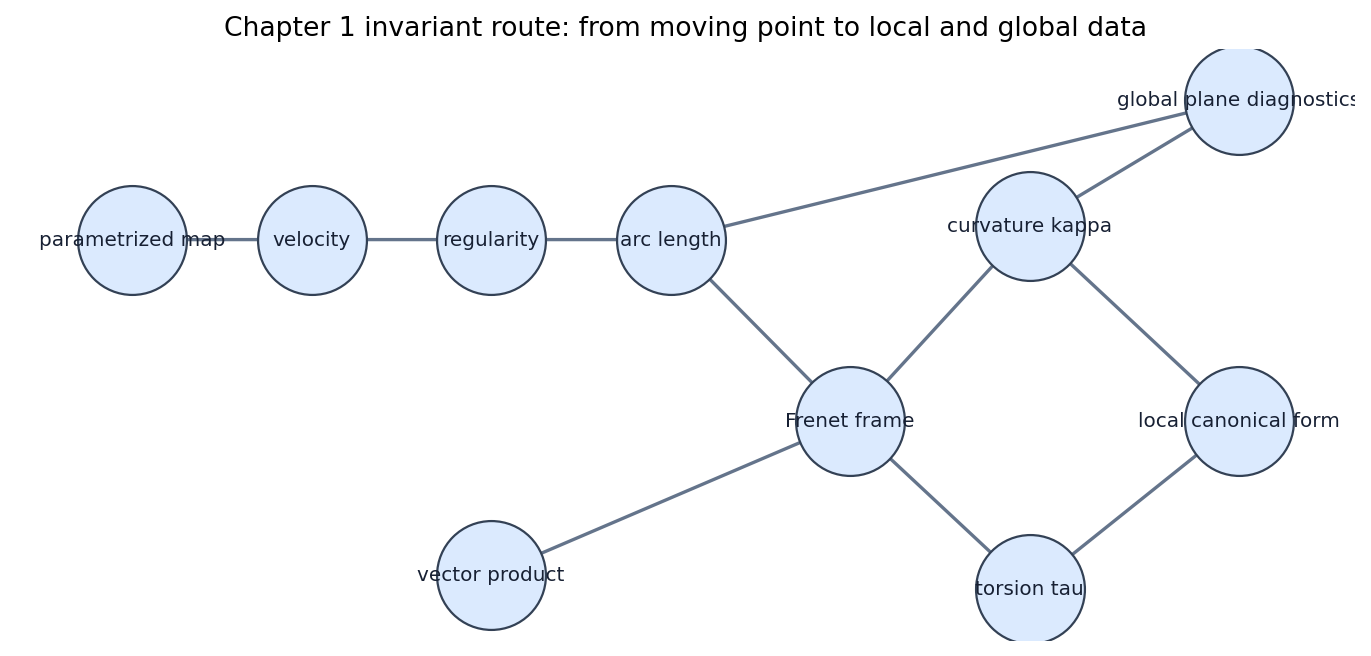

**regularity**

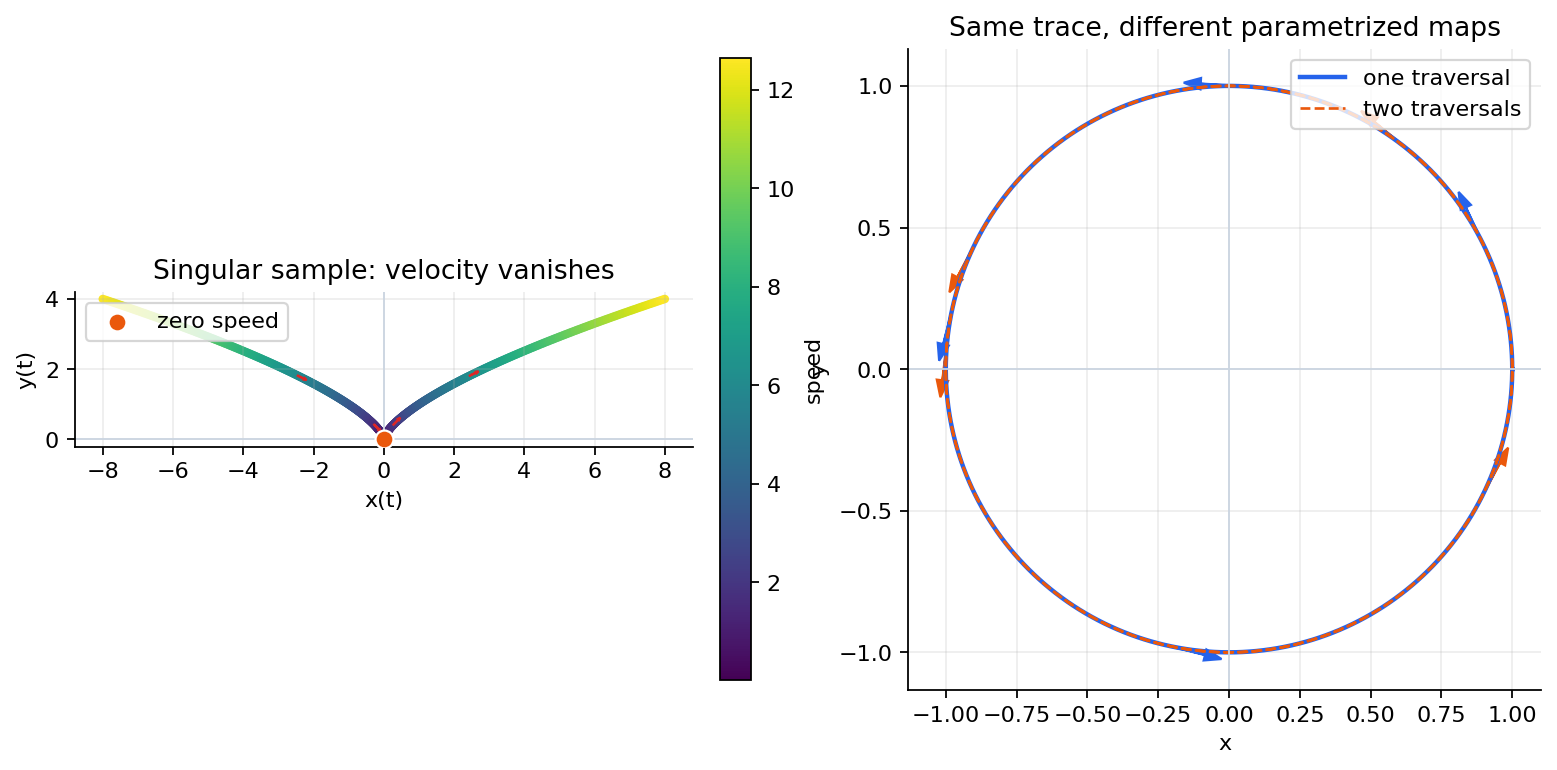

**arc_clock**

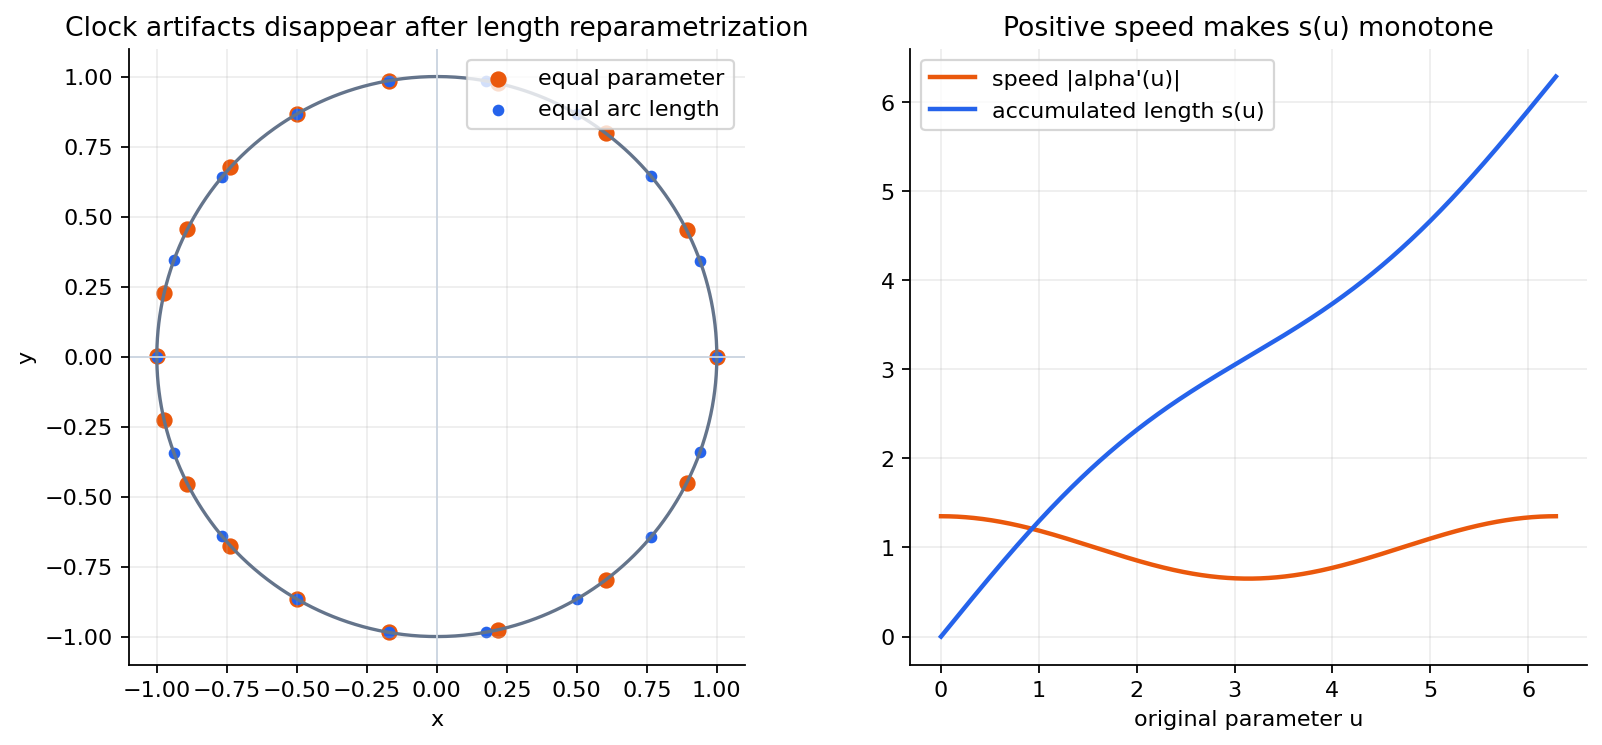

**frenet_frame**

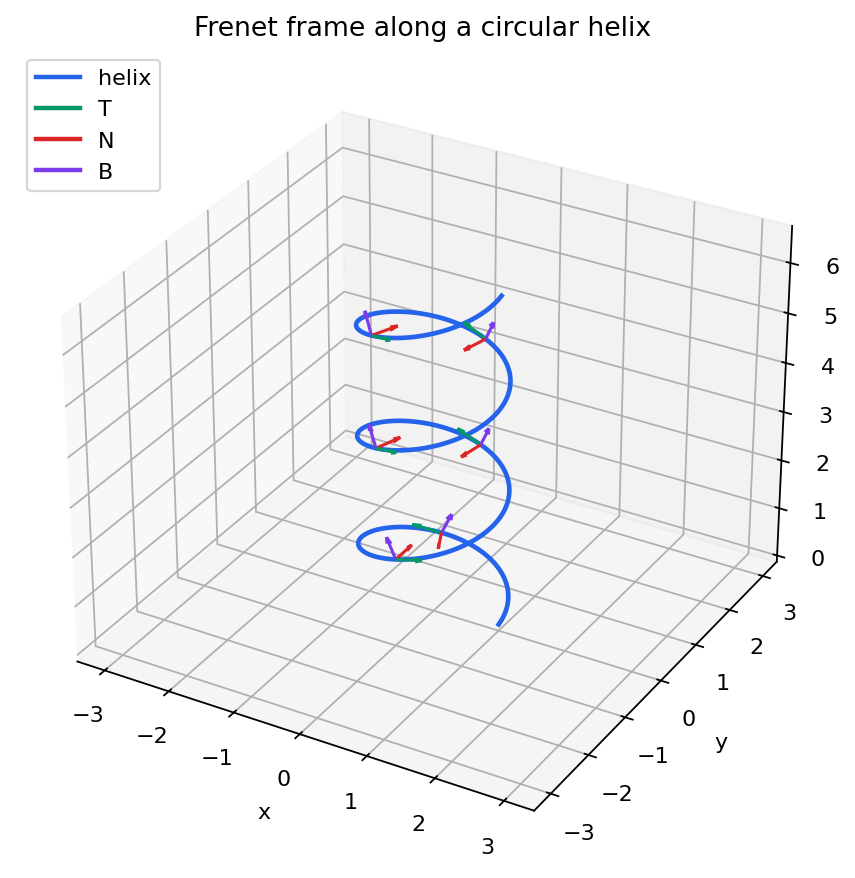

**local_canonical**

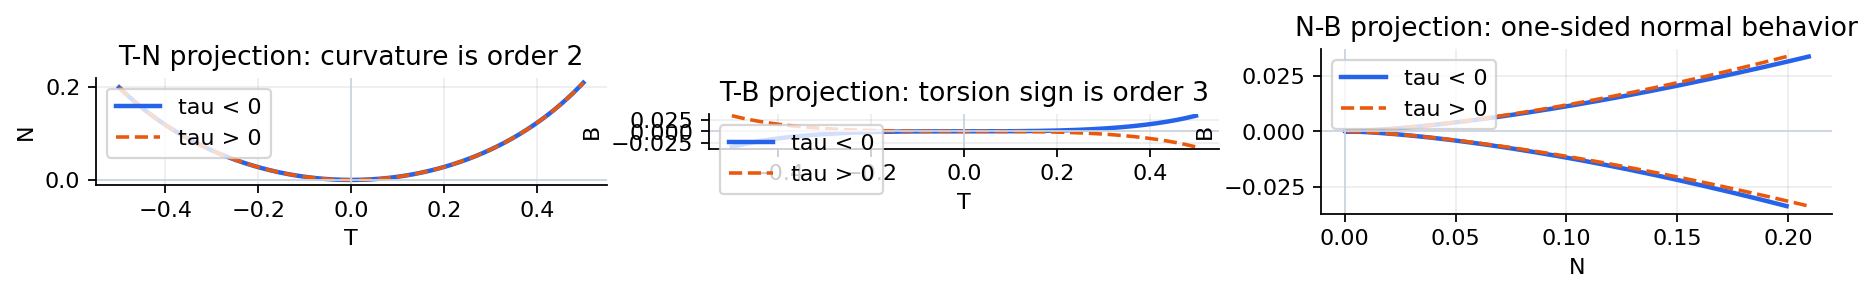

**osculating_circle**

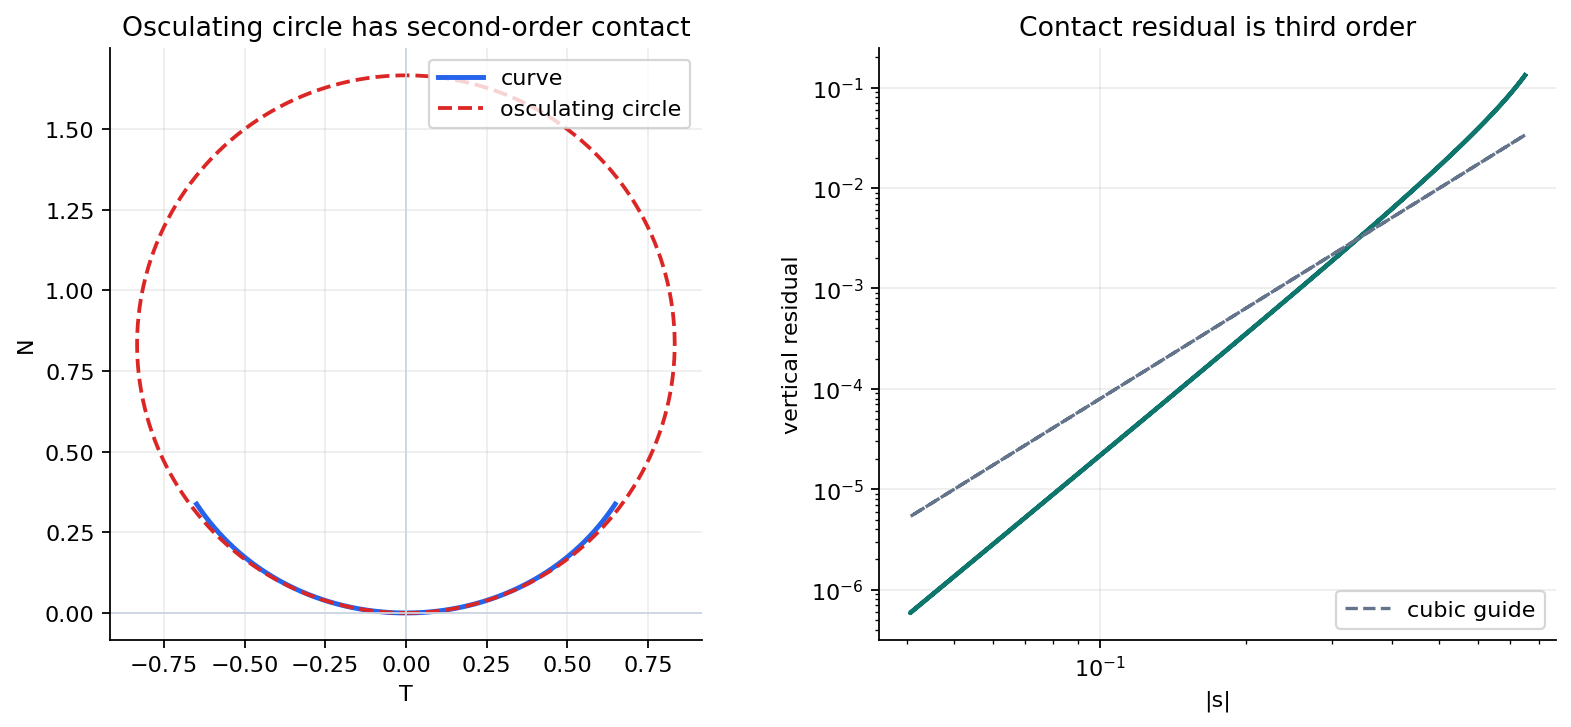

**global_diagnostics**

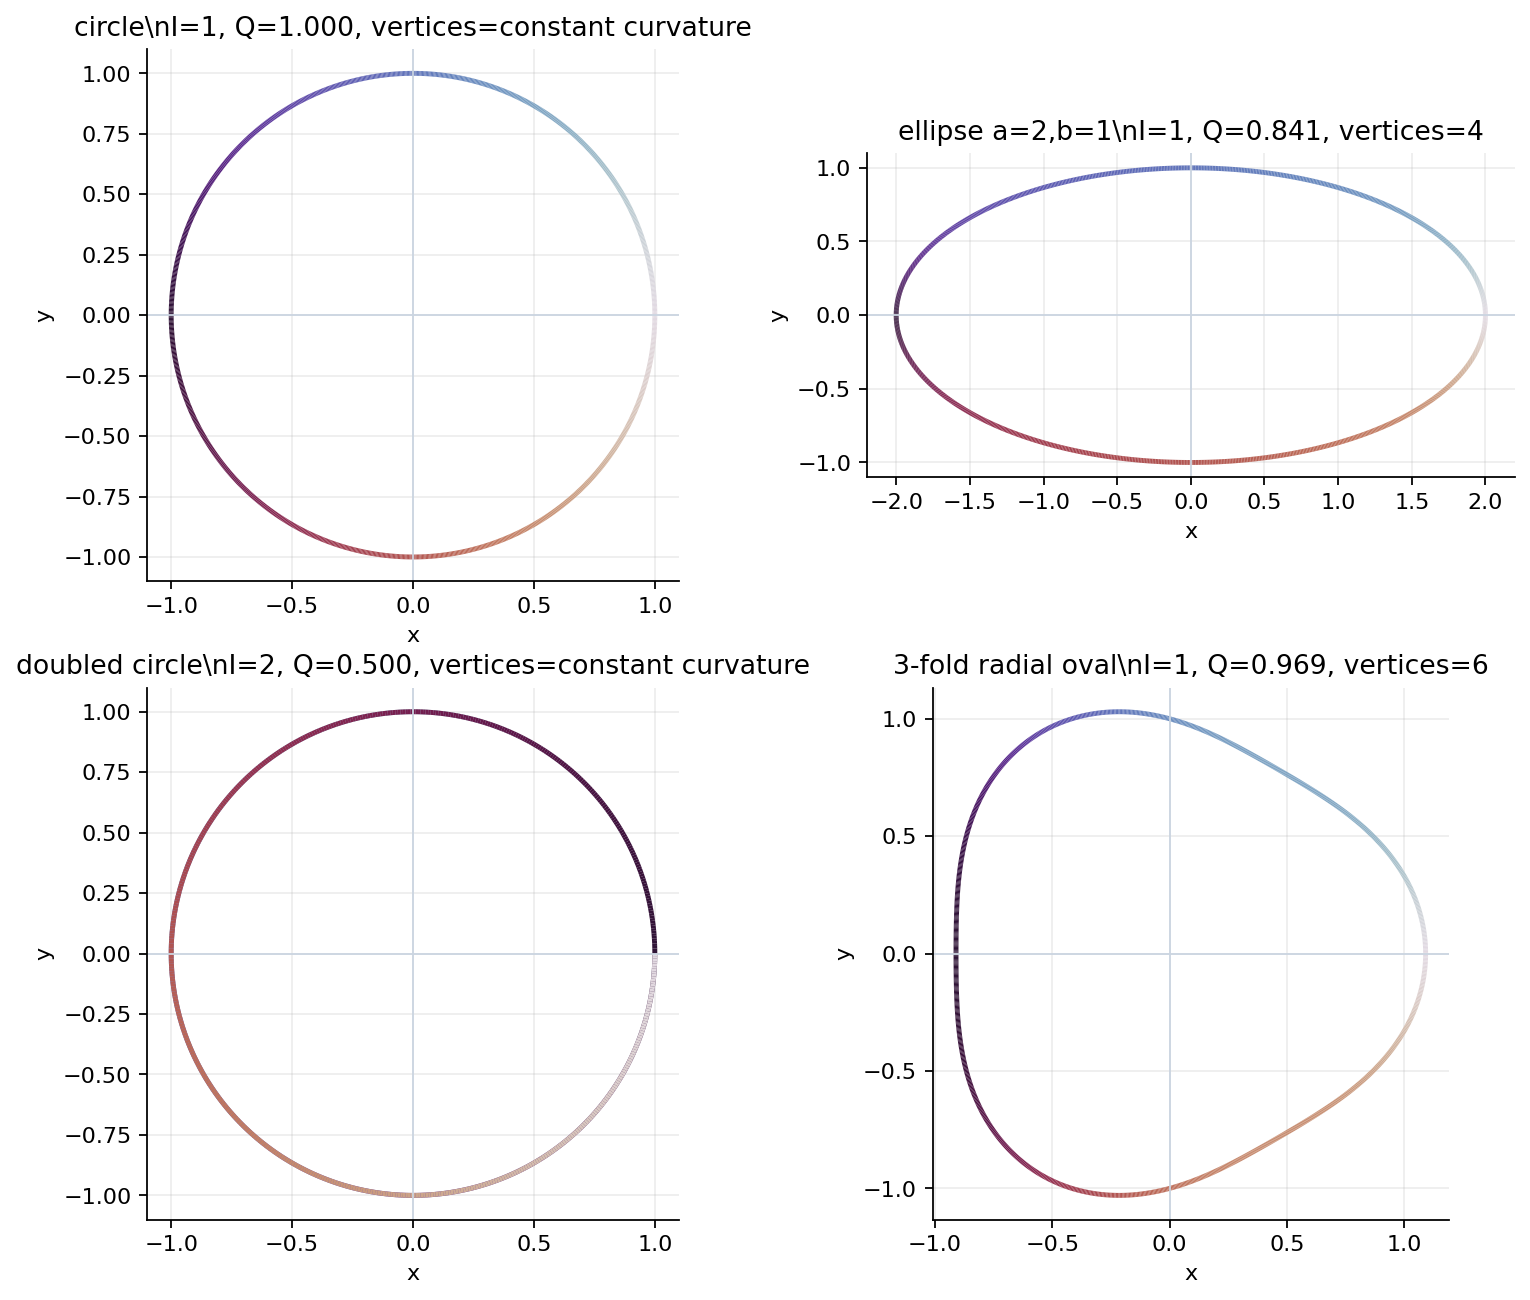

**applied_lab**

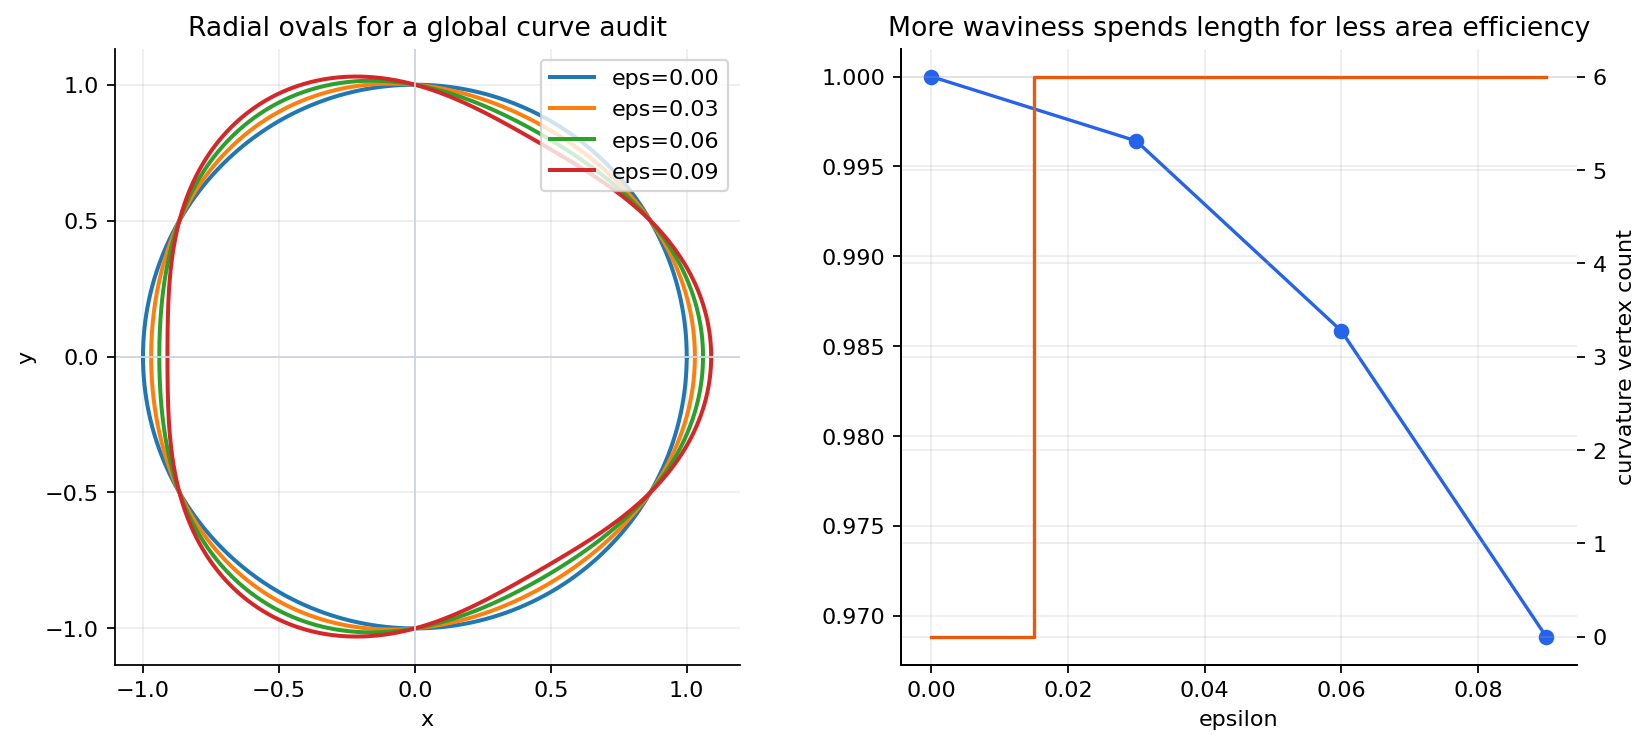

,name,length,area,rotation_index,isoperimetric_deficit,isoperimetric_quotient,vertex_count,min_signed_curvature,max_signed_curvature,simple_model
0,circle,6.283157,3.141578,1.0,-0.000180,1.000005,constant curvature,1.000007,1.000007,True
1,"ellipse a=2,b=1",9.688404,6.283157,1.0,14.908697,0.841169,4,0.250002,2.000014,True
2,doubled circle,12.566141,6.283070,2.0,78.952506,0.500009,constant curvature,1.000027,1.000027,False
3,3-fold radial oval,6.396357,3.154300,1.0,1.275280,0.968830,6,0.120788,1.599214,True


,epsilon,rotation_index,isoperimetric_quotient,vertex_count,min_signed_curvature
0,0.00,1.0,1.000005,constant curvature,1.000007
1,0.03,1.0,0.996421,6,0.743977
2,0.06,1.0,0.985853,6,0.452709
3,0.09,1.0,0.968830,6,0.120788


In [3]:
for key in ['route_map', 'regularity', 'arc_clock', 'frenet_frame', 'local_canonical', 'osculating_circle', 'global_diagnostics', 'applied_lab']:
    display(Markdown(f'**{key}**'))
    display_artifact(paths[key], width=860)
display(pd.read_csv(paths['global_table']))
display(pd.read_csv(paths['applied_lab_table']))

## Interactive 3D Frame Inspection

Rotate the helix artifact to inspect how `T`, `N`, and `B` move together. This is the most useful representation for the spatial part of Chapter 1 because binormal twist is hard to read from a fixed 2D projection.

In [4]:
display_artifact(paths['interactive'], height=520)

## Applied Lab

The lab audits the radial family `r(theta) = 1 + epsilon cos(3 theta)`. Increase `epsilon` and watch the global diagnostics: length efficiency drops, the rotation index stays fixed, and curvature vertices appear once the circle stops having constant curvature.

The artifact and CSV table were generated above so the lab is reproducible without manual measurement.

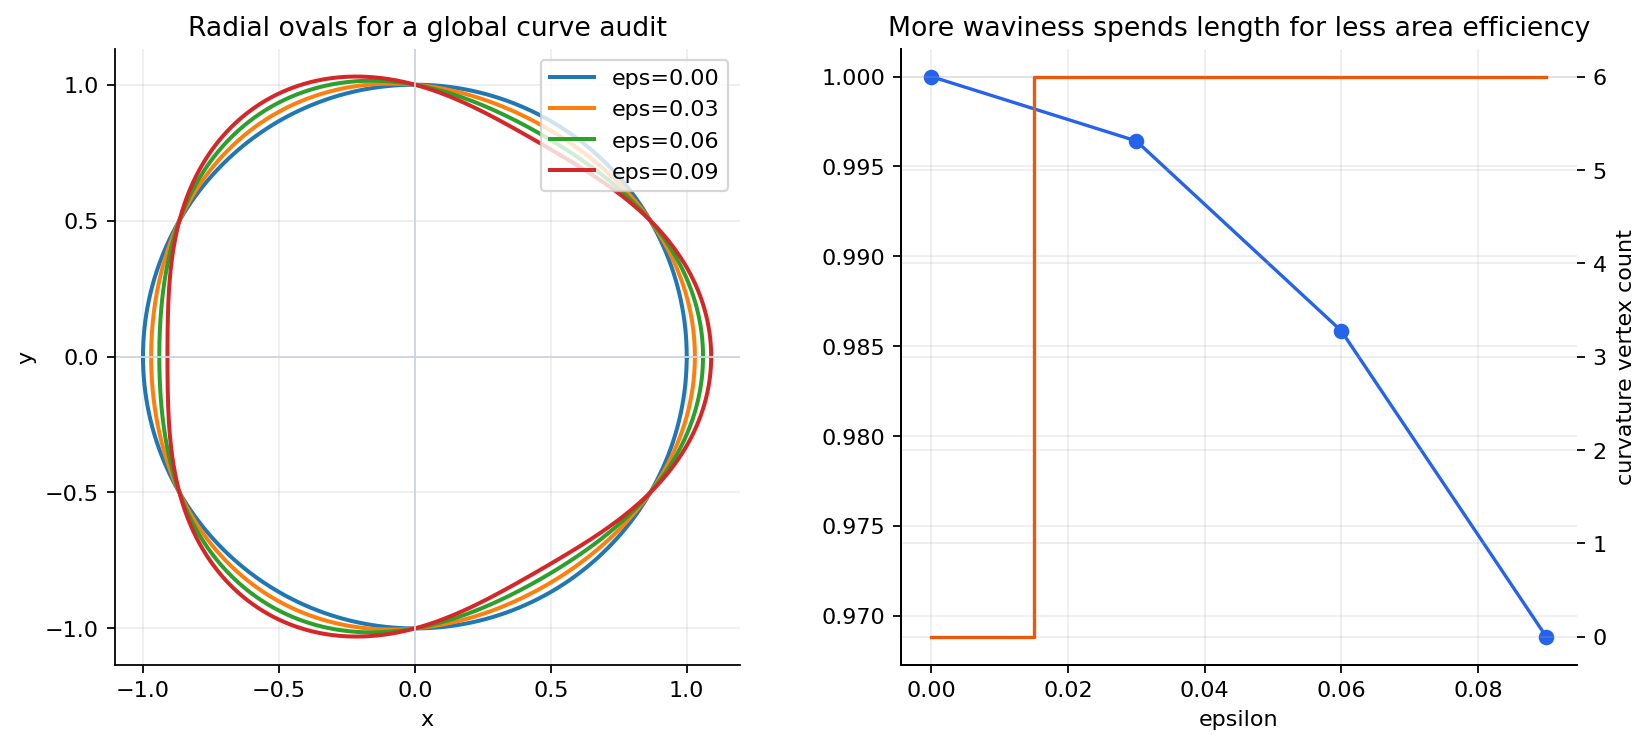

,epsilon,rotation_index,isoperimetric_quotient,vertex_count,min_signed_curvature
0,0.00,1.0,1.000005,constant curvature,1.000007
1,0.03,1.0,0.996421,6,0.743977
2,0.06,1.0,0.985853,6,0.452709
3,0.09,1.0,0.968830,6,0.120788


In [5]:
display_artifact(paths['applied_lab'], width=860)
lab_df = pd.read_csv(paths['applied_lab_table'])
assert checks['applied_lab']['isoperimetric_quotient_nonincreasing']
assert checks['applied_lab']['positive_curvature_for_tested_ovals']
display(lab_df)

## Sanity Checks

The notebook ends by checking that all generated artifacts exist, have nonzero size, and that the JSON ledger is present as `final-sanity.json`. The numerical checks are deliberately modest: they certify the visual story without pretending to replace a proof.

In [6]:
def min_bytes_for(path):
    return 32 if Path(path).suffix.lower() in {'.json', '.csv'} else 512

assert checks['regularity']['cusp_min_speed'] < 1e-2
assert checks['regularity']['circle_once_min_speed'] > .99
assert checks['arc_length']['arc_length_monotone']
assert checks['arc_length']['total_length_error_vs_2pi'] < 5e-4
assert checks['symbolic_helix']['curvature_identity_zero'] == '0'
assert checks['symbolic_helix']['torsion_identity_zero'] == '0'
assert checks['frenet_frame']['max_abs_T_cross_N_minus_B'] < 1e-12
assert checks['frenet_frame']['frenet_T_prime_residual'] < 2e-3
assert checks['frenet_frame']['frenet_N_prime_residual'] < 2e-3
assert checks['frenet_frame']['frenet_B_prime_residual'] < 2e-3
assert checks['local_canonical']['negative_tau_positive_s_binormal_sign'] > 0
assert checks['local_canonical']['positive_tau_positive_s_binormal_sign'] < 0
assert checks['global_plane_curves']['circle_rotation_index_error'] < 1e-6
assert checks['global_plane_curves']['circle_isoperimetric_quotient_error'] < 5e-4
assert checks['global_plane_curves']['ellipse_vertex_count'] == 4
assert abs(checks['global_plane_curves']['doubled_circle_rotation_index'] - 2) < 1e-6
assert checks['applied_lab']['isoperimetric_quotient_nonincreasing']
assert checks['applied_lab']['positive_curvature_for_tested_ovals']

artifact_sizes = {}
for name, path in ARTIFACTS.items():
    artifact_sizes[name] = assert_artifact(path, min_bytes=min_bytes_for(path)).stat().st_size
final_sanity = {'unit': UNIT, 'source_span': SOURCE_SPAN, 'artifact_count_before_final_json': len(ARTIFACTS), 'artifact_sizes': {k: int(v) for k, v in artifact_sizes.items()}, 'checks': checks, 'core_assertions': {'regularity_arc_length_frenet_local_global_lab': True, 'artifact_integrity': True}}
final_path = write_json(final_sanity, UNIT, 'checks', 'final-sanity.json')
paths['final_sanity'] = nb_rel(remember('final_sanity', final_path))
assert_artifact(final_path, min_bytes=512)
display(pd.DataFrame([{'artifact': name, 'path': rel(path), 'bytes': Path(path).stat().st_size} for name, path in ARTIFACTS.items()]).sort_values('artifact'))
final_sanity

,artifact,path,bytes
17,applied_lab,artifacts/chapter-01/figures/applied-lab-radia...,148868
19,applied_lab_summary,artifacts/chapter-01/checks/applied-lab-summar...,222
18,applied_lab_table,artifacts/chapter-01/tables/applied-lab-radial...,299
5,arc_clock,artifacts/chapter-01/figures/arc-length-clock.png,110604
6,arc_length_checks,artifacts/chapter-01/checks/arc-length-checks....,127
20,final_sanity,artifacts/chapter-01/checks/final-sanity.json,2552
9,frenet_frame,artifacts/chapter-01/figures/helix-frenet-fram...,136841
8,frenet_frame_invariants,artifacts/chapter-01/checks/frenet-frame-invar...,288
14,global_diagnostics,artifacts/chapter-01/figures/global-plane-curv...,216573
16,global_plane_curve_checks,artifacts/chapter-01/checks/global-plane-curve...,212


{'unit': 'chapter-01',
 'source_span': {'printed_pages': '1-52',
  'pdf_pages': '17-68',
  'source_map': 'pdf_page = printed_page + 16'},
 'artifact_count_before_final_json': 20,
 'artifact_sizes': {'source_span': 105,
  'visual_storyboard': 1444,
  'route_map': 87910,
  'regularity': 104692,
  'regularity_checks': 129,
  'arc_clock': 110604,
  'arc_length_checks': 127,
  'symbolic_formulas': 115,
  'frenet_frame_invariants': 288,
  'frenet_frame': 136841,
  'interactive': 4886356,
  'local_canonical': 78060,
  'osculating_circle': 97621,
  'local_canonical_checks': 146,
  'global_diagnostics': 216573,
  'global_table': 740,
  'global_plane_curve_checks': 212,
  'applied_lab': 148868,
  'applied_lab_table': 299,
  'applied_lab_summary': 222},
 'checks': {'regularity': {'cusp_min_speed': 0.00572251336152462,
   'circle_once_min_speed': 0.9999999999999999,
   'circle_twice_speed_ratio': 2.0},
  'arc_length': {'speed_min': 0.6500021370661662,
   'arc_length_monotone': True,
   'total_leng

## Takeaways

- Always distinguish parametrized map, trace, and chosen clock.
- Regularity is the certificate that tangent geometry exists.
- Arc length removes clock artifacts from local formulas.
- Curvature is visible through turning and osculating circles; torsion is visible through binormal twist.

The next chapter should be read with these computational habits intact: identify the object, name the local certificate, build a visual model, and keep a small numerical or symbolic check close to the picture.